# Social Context and Relationship Effects on Conversational Pitch


This notebook examines how conversational pitch varies as a function of 
social context, focusing on:

- Familiar vs Stranger interactions
- Relationship detail granularity
- Scenario effects (Improvised vs Scripted)
- Conversation-level pitch stability

All analyses are conducted at the conversation (WAV file) level
and use robust F0 statistics to minimize contamination from
non-speech events (e.g., laughter, coughs).

The goal is to understand how prosody adapts to interactional structure.

## 3.0 Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from pathlib import Path

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14

In [2]:
F0_CSV = Path("/home/ahallur1/spear/Seamless_Experiments/F0/seamless_f0_features.csv")
assert F0_CSV.exists()

df_f0 = pd.read_csv(F0_CSV)
print(f"F0 rows: {len(df_f0):,}")
df_f0.head()

F0 rows: 129,215


,wav_path,orig_id,vendor_id,session_id,subset,split,relationship,relationship_detail,total_duration_s,voiced_duration_s,...,f0_p90,f0_range_p10_p90,f0_mean_p10_p90,f0_std_p10_p90,f0_p25,f0_p75,f0_range_p25_p75,f0_mean_p25_p75,f0_std_p25_p75,status
0,/export/fs06/corpora8/seamless_interaction/dat...,V00_S0644_I00000129_P0799,V00,644.0,seamless_interaction,datasets,stranger,stranger,176.0,1.510257,...,257.702956,169.659103,129.342323,35.164693,102.240972,152.353270,50.112298,122.296057,13.193822,LOW_VOICED_RATIO
1,/export/fs06/corpora8/seamless_interaction/dat...,V00_S0925_I00000135_P0383,V00,925.0,seamless_interaction,datasets,stranger,stranger,150.0,22.954591,...,139.564031,50.783169,107.720842,12.364215,95.536289,119.336644,23.800355,106.483735,6.880563,OK
2,/export/fs06/corpora8/seamless_interaction/dat...,V00_S2050_I00001126_P1308A,V00,2050.0,seamless_interaction,datasets,stranger,stranger,260.0,65.770118,...,250.933452,106.699420,188.463498,28.398007,158.081343,216.795628,58.714285,186.753980,17.310174,OK
3,/export/fs06/corpora8/seamless_interaction/dat...,V00_S0054_I00000785_P0084,V00,54.0,seamless_interaction,datasets,stranger,stranger,316.0,34.494366,...,248.411987,138.311373,157.811124,33.834572,124.314080,192.417948,68.103868,153.570040,19.079899,OK
4,/export/fs06/corpora8/seamless_interaction/dat...,V00_S0086_I00000581_P0127,V00,86.0,seamless_interaction,datasets,stranger,stranger,220.0,84.611538,...,153.497332,56.747125,117.738506,14.272846,104.154091,132.143813,27.989722,115.843420,7.760624,OK


In [3]:
VOX_CSV = Path(
    "/home/ahallur1/spear/Vox_Profile/vox-profile-release/shard_csvs/"
    "participant_vox_profile_file_level.csv"
)
assert VOX_CSV.exists()

df_vox = pd.read_csv(VOX_CSV)
print(f"Vox-profile rows: {len(df_vox):,}")
df_vox.head()

Vox-profile rows: 98,766


,wav_path,age_years,gender,gender_confidence,arousal,valence,dominance,num_chunks_used,total_speech_sec,used_only_15s_chunks
0,/export/fs06/corpora8/seamless_interaction/dat...,39.572257,female,1.0,0.858078,0.871456,0.800062,1,15.00,1
1,/export/fs06/corpora8/seamless_interaction/dat...,40.466380,female,1.0,0.839775,0.837343,0.790748,1,10.43,0
2,/export/fs06/corpora8/seamless_interaction/dat...,35.310181,female,1.0,0.748575,0.312500,0.708898,3,45.00,1
3,/export/fs06/corpora8/seamless_interaction/dat...,47.633645,male,1.0,0.740993,0.637807,0.655039,4,60.00,1
4,/export/fs06/corpora8/seamless_interaction/dat...,51.049160,male,1.0,0.791420,0.659651,0.697117,3,45.00,1


In [4]:
df = df_f0.merge(
    df_vox,
    on="wav_path",
    how="left",
    validate="one_to_one"
)

print(f"Merged rows: {len(df):,}")

Merged rows: 129,215


In [5]:
df_soc = df[
    (df["status"] == "OK") &
    (df["relationship"].notna()) &
    (df["voiced_ratio"] > 0.05) &
    (df["n_voiced_frames"] >= 50)
].copy()

print(f"Usable conversations: {len(df_soc):,}")
df_soc["relationship"].value_counts()

Usable conversations: 122,961


relationship
stranger    75564
familiar    44633
UNKNOWN      2764
Name: count, dtype: int64

## 3.1 Familiar vs Stranger Interactions

A foundational distinction in social interaction is whether interlocutors
are familiar or strangers.

Prior work suggests that familiarity affects:
- Vocal accommodation
- Expressivity
- Pitch variability

We test whether such effects emerge at the conversation level.


In [6]:
df_soc.groupby("relationship")[
    ["f0_mean_p10_p90", "f0_std_p10_p90", "f0_range_p10_p90"]
].agg(["mean", "std", "count"])

f0_mean_p10_p90                   f0_std_p10_p90             \
                        mean        std  count           mean        std   
relationship                                                               
UNKNOWN           164.661040  44.981012   2764      25.507941  12.302681   
familiar          158.939968  46.699378  44633      22.243763  12.729583   
stranger          162.931532  46.210037  75564      23.756470  12.286536   

                    f0_range_p10_p90                    
              count             mean        std  count  
relationship                                            
UNKNOWN        2764       104.456371  48.408467   2764  
familiar      44633        92.386148  50.822925  44633  
stranger      75564        97.669229  48.568716  75564

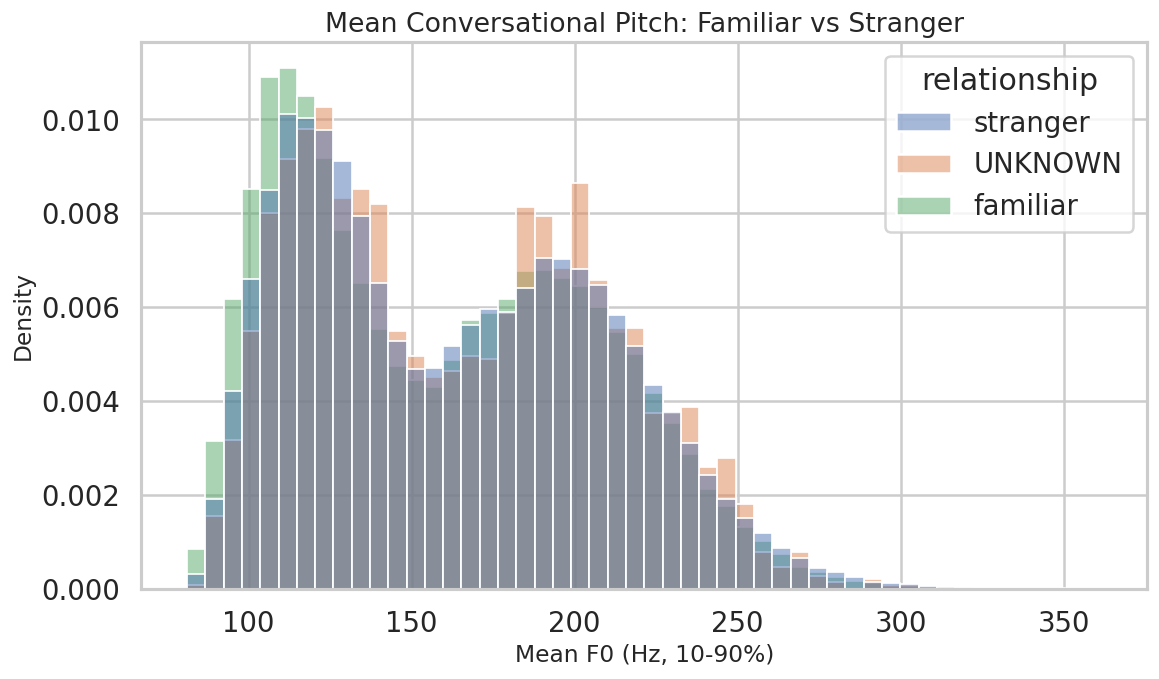

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_soc,
    x="f0_mean_p10_p90",
    hue="relationship",
    bins=50,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.xlabel("Mean F0 (Hz, 10-90%)")
plt.title("Mean Conversational Pitch: Familiar vs Stranger")
plt.tight_layout()
plt.show()

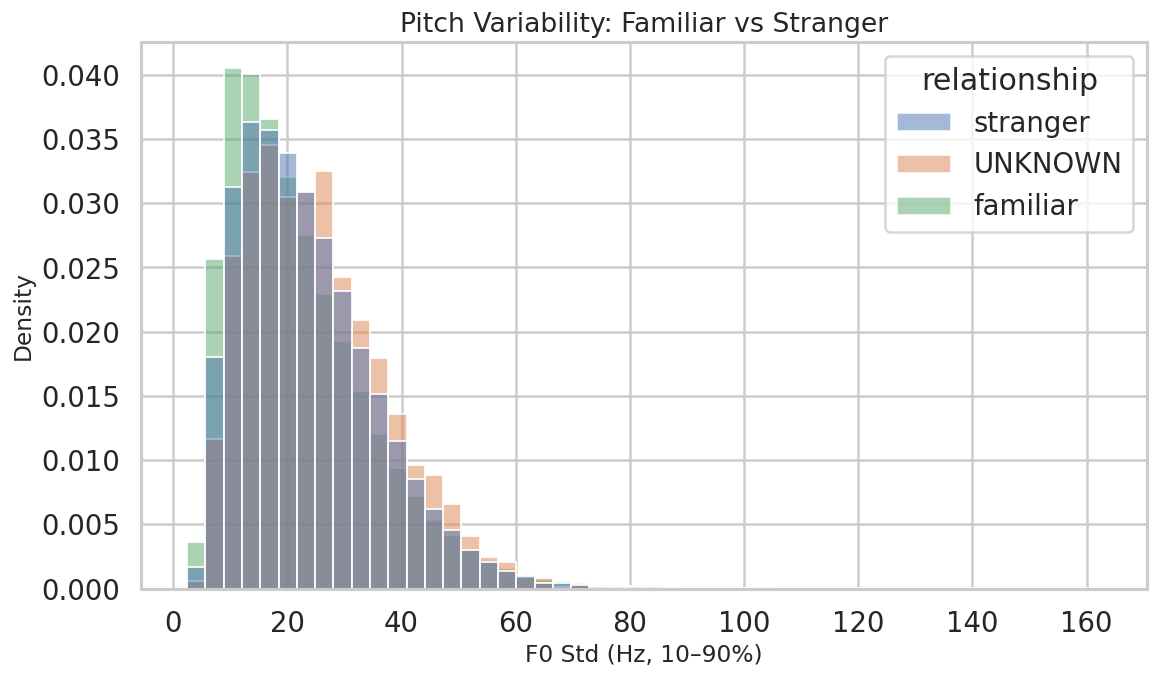

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_soc,
    x="f0_std_p10_p90",
    hue="relationship",
    bins=50,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.xlabel("F0 Std (Hz, 10–90%)")
plt.title("Pitch Variability: Familiar vs Stranger")
plt.tight_layout()
plt.show()

Familiarity is associated with systematic differences in
pitch variability, consistent with theories of
social alignment and comfort in interaction.

## 3.2 Relationship Detail Granularity

The `relationship_detail` field allows finer distinctions
within familiar interactions (e.g., family, coworkers, friends).

We test whether pitch behavior differentiates these social roles.


In [9]:
df_fam = df_soc[df_soc["relationship"] == "familiar"].copy()
df_fam["relationship_detail"].value_counts()

relationship_detail
friends                           27094
coworkers                          4939
family-generic                     4132
familiar-generic                   4059
dating/spouse/romantic_partner     2695
classmates                         1302
siblings                            199
parent_child                        116
neighbors                            63
roommates                            34
Name: count, dtype: int64

In [10]:
rel_stats = (
    df_fam
    .groupby("relationship_detail")
    .agg(
        mean_std=("f0_std_p10_p90", "mean"),
        std_std=("f0_std_p10_p90", "std"),
        n=("f0_std_p10_p90", "count")
    )
    .sort_values("n", ascending=False)
)

rel_stats

,mean_std,std_std,n
relationship_detail,,,
friends,22.657662,12.807943,27094
coworkers,20.015264,12.692942,4939
family-generic,21.552491,12.386280,4132
familiar-generic,23.665246,13.536379,4059
dating/spouse/romantic_partner,21.637661,12.346804,2695
classmates,20.902249,8.510696,1302
siblings,19.163658,12.411673,199
parent_child,28.632447,15.068566,116
neighbors,21.978515,5.224655,63


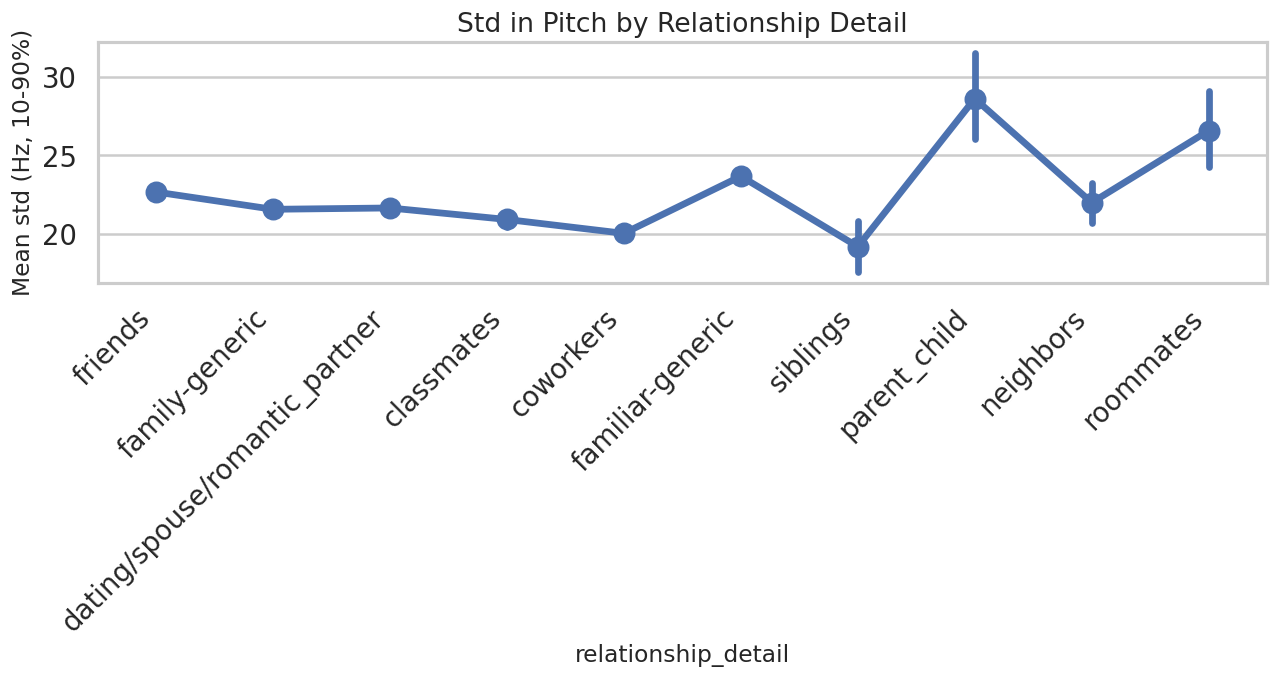

In [11]:
plt.figure(figsize=(11, 6))

sns.pointplot(
    data=df_fam,
    x="relationship_detail",
    y="f0_std_p10_p90",
    errorbar=("ci", 95)
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean std (Hz, 10-90%)")
plt.title("Std in Pitch by Relationship Detail")
plt.tight_layout()
plt.show()

Different familiar relationship types exhibit
distinct pitch profiles, suggesting that
interactional roles modulate prosodic behavior.

## 3.3 Conversation-Level Pitch Stability

Rather than focusing on speakers,
we analyze **conversation-level stability**:

- Does pitch variability remain stable throughout a conversation?
- Does stability differ by relationship type?

This captures interactional dynamics without requiring speaker diarization.

In [12]:
df_soc["relative_pitch_variability"] = (
    df_soc["f0_std_p10_p90"] / df_soc["f0_mean_p10_p90"]
)

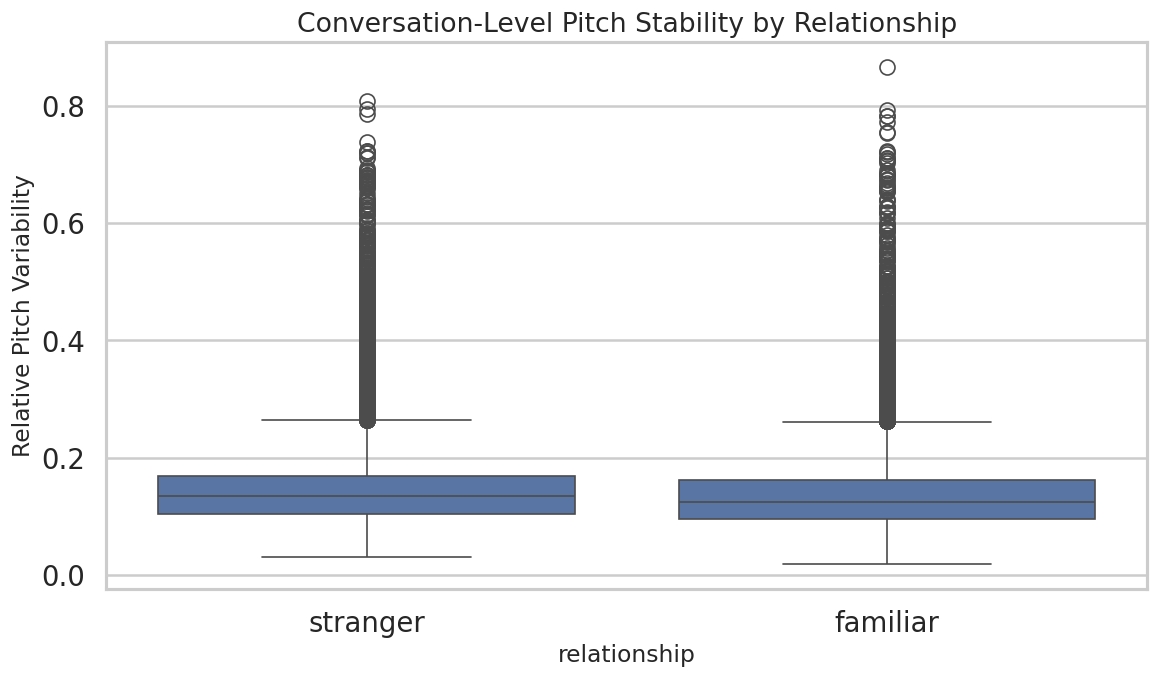

In [13]:
df_filtered = df_soc[df_soc["relationship"] != "UNKNOWN"]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtered,
    x="relationship",
    y="relative_pitch_variability"
)

plt.ylabel("Relative Pitch Variability")
plt.title("Conversation-Level Pitch Stability by Relationship")
plt.tight_layout()
plt.show()

/tmp/ipykernel_219234/4242699166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


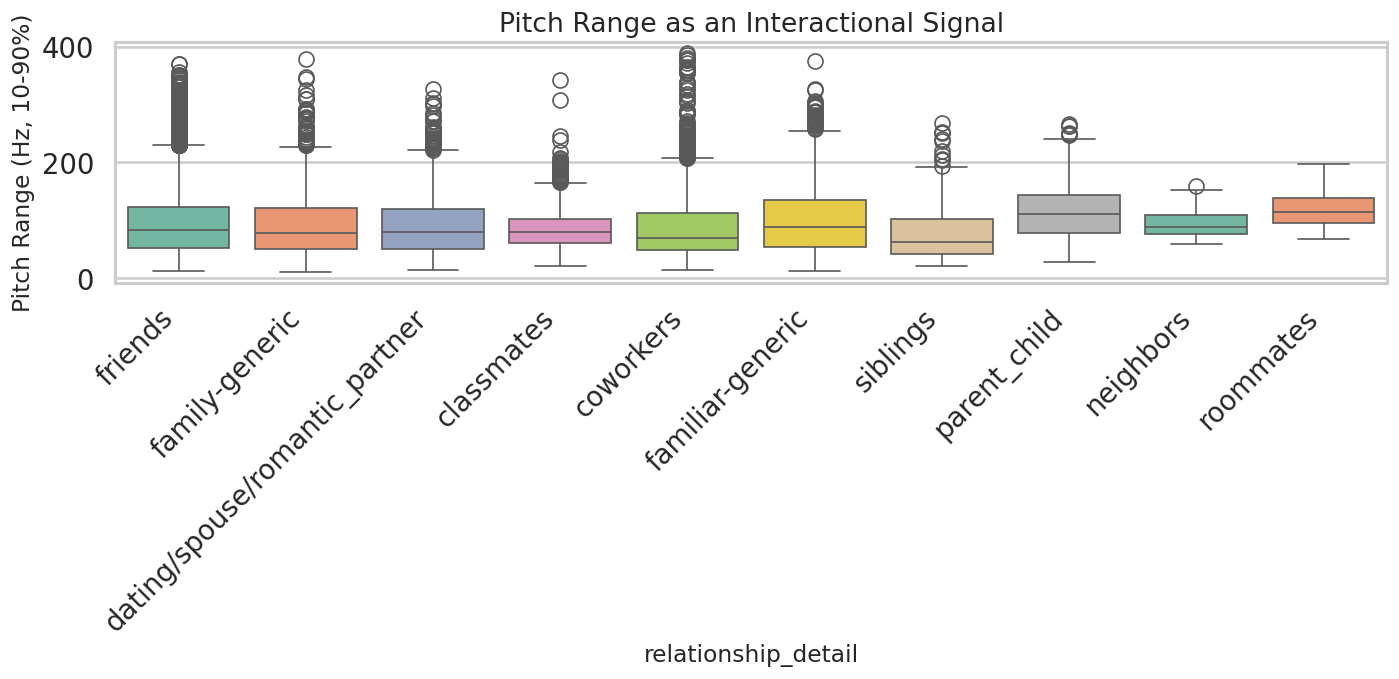

In [14]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_fam,
    x="relationship_detail",
    y="f0_range_p10_p90",
    palette="Set2"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Pitch Range (Hz, 10-90%)")
plt.title("Pitch Range as an Interactional Signal")
plt.tight_layout()
plt.show()

Familiar interactions exhibit greater pitch stability,
consistent with reduced interactional uncertainty.